<a href="https://colab.research.google.com/github/nicoavilan/Clases/blob/main/ciencia_datos_huerta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/nicoavilan/Clases/blob/main/ciencia_datos_huerta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ciencia de datos en nuestra huerta 🌱**
### Sesión 2

[Nicolás Avilán Vargas](http://www.linkedin.com/in/nicoavilanv)

Correo electrónico: nicolasg.avilan@urosario.edu.co

[Matemáticas Aplicadas y Ciencias de la Computación - MACC](https://urosario.edu.co/matematicas-aplicadas-y-ciencias-de-la-computacion-macc)

## Pregunta guía

En la huerta hay sensores que midieron **416 veces** tres cosas:

| Variable | ¿Qué mide? | Unidad |
|---|---|---|
| Humedad relativa | Cuánta agua hay en el **aire** | % |
| Temperatura | Qué tan caliente está el aire | °C |
| Humedad del suelo | Cuánta agua hay en la **tierra** | % |

Hoy vamos a actuar como científicas de datos para responder:

> **¿Qué nos dicen los sensores sobre nuestra huerta? ¿Podemos confiar en todos los datos? ¿Cuándo necesitan agua las plantas?**

### Plan de la sesión (90 minutos)

| # | Tema | Tiempo |
|---|---|---|
| 1 | Repaso y librerías | 5 min |
| 2 | Cargar datos reales desde Excel | 10 min |
| 3 | Explorar los datos | 10 min |
| 4 | Graficar los datos en el tiempo | 15 min |
| 5 | Limpiar datos: ¿todos los datos son confiables? | 15 min |
| 6 | Distribuciones: histogramas | 10 min |
| 7 | Relaciones entre variables | 10 min |
| 8 | Semáforo de riego | 10 min |
| 9 | Conclusiones | 5 min |

## 1. Repaso y librerías (5 min)

En la sesión anterior aprendimos que las **librerías** son cajas de herramientas. Usaremos las mismas tres:

In [ ]:
import numpy as np               # Para manipular números
import pandas as pd              # Para manipular tablas de datos
import matplotlib.pyplot as plt  # Para hacer gráficas

**Repaso rápido:** ¿recuerdas qué hacían `df.describe()`, `df.Temperatura.max()` y `plt.plot(x, y)`? ¡Hoy los usaremos todos!

## 2. Cargar datos reales desde Excel (10 min)

En la sesión 1 cargamos un archivo `.csv` desde internet. Hoy usaremos **nuestros propios datos**, que están en una hoja de cálculo de Excel.

**Antes de ejecutar:** en Colab, abre el panel de archivos (📁 a la izquierda) y arrastra ahí el archivo `Monitoreo_Agroclimatico_Completo_415_Muestras.xlsx`.

In [ ]:
archivo = "/content/Monitoreo_Agroclimatico_Completo_415_Muestras.xlsx"

# Un archivo de Excel puede tener varias hojas. ¿Cuáles tiene el nuestro?
pd.ExcelFile(archivo).sheet_names

['Dashboard Agroclimático', 'Registro de Datos']

Leamos la hoja `Registro de Datos` sin decirle nada más a pandas:

In [ ]:
primer_intento = pd.read_excel(archivo, sheet_name="Registro de Datos")
primer_intento.head(8)

,REGISTRO DETALLADO DE MONITOREO AMBIENTAL Y SUELO,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Total de muestras capturadas: 416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Muestra #,Humedad Relativa (%),Temperatura (°C),Humedad de Suelo (%),NaN,Métrica Estadística,Humedad Relativa (%),Temperatura (°C),Humedad Suelo (%)
3,1,72,17,0,NaN,Promedio,67.10,19.81,47.18
4,2,66,17,0,NaN,Mínimo,46.00,15.00,0.00
5,3,77,15,56,NaN,Máximo,86.00,30.00,79.00
6,4,74,21,16,NaN,Mediana,66.00,19.00,58.00
7,5,62,22,14,NaN,Desv. Estándar,8.97,3.02,26.81


😬 **¡Qué desorden!** Hay títulos, filas vacías, columnas `Unnamed` y una tablita de resumen a la derecha.

Esto es muy común con datos reales: las hojas de cálculo están hechas para que las **lean personas**, no computadores. Por eso le damos instrucciones a pandas:

- `header=3`: los nombres de las columnas están en la **cuarta** fila (Python empieza a contar desde 0).
- `usecols="A:D"`: solo queremos las columnas de la A a la D.

In [ ]:
df = pd.read_excel(archivo, sheet_name="Registro de Datos", header=3, usecols="A:D")
df.head()

,Muestra #,Humedad Relativa (%),Temperatura (°C),Humedad de Suelo (%)
0,1,72,17,0
1,2,66,17,0
2,3,77,15,56
3,4,74,21,16
4,5,62,22,14


Los nombres de las columnas tienen espacios, tildes y símbolos. Les ponemos nombres cortos para poder escribir `df.Temperatura` como en la sesión 1:

In [ ]:
df.columns = ["Muestra", "HumedadAire", "Temperatura", "HumedadSuelo"]
df

,Muestra,HumedadAire,Temperatura,HumedadSuelo
0,1,72,17,0
1,2,66,17,0
2,3,77,15,56
3,4,74,21,16
4,5,62,22,14
...,...,...,...,...
411,412,69,20,76
412,413,76,21,67
413,414,74,20,74
414,415,76,20,76


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Muestra       416 non-null    int64
 1   HumedadAire   416 non-null    int64
 2   Temperatura   416 non-null    int64
 3   HumedadSuelo  416 non-null    int64
dtypes: int64(4)
memory usage: 13.1 KB


**Ejercicio 2.1:** ¿Cuántas muestras (filas) tenemos? Pista: usa `len(df)`.

In [ ]:
# Escribe tu código aquí

## 3. Explorar los datos (10 min)

In [ ]:
round(df.describe(), 1)

,Muestra,HumedadAire,Temperatura,HumedadSuelo
count,416.0,416.0,416.0,416.0
mean,208.5,67.1,19.8,47.2
std,120.2,9.0,3.0,26.8
min,1.0,46.0,15.0,0.0
25%,104.8,61.0,17.0,26.8
50%,208.5,66.0,19.0,58.0
75%,312.2,73.0,21.0,69.0
max,416.0,86.0,30.0,79.0


Recuerda:
- `mean` = promedio, `std` = desviación estándar (qué tanto se alejan los datos del promedio)
- `min` y `max` = valores mínimo y máximo
- `50%` = **mediana**: la mitad de los datos está por debajo de este valor y la otra mitad por encima.

**Ejercicio 3.1:** Imprime la temperatura máxima, la mínima y el promedio.

In [ ]:
# Escribe tu código aquí

**Ejercicio 3.2 (para pensar 🤔):** Mira la columna `HumedadSuelo` en la tabla de `describe()`.

- ¿Cuál es el valor mínimo? ¿Tiene sentido que la tierra de una huerta tenga **0 %** de agua?
- Compara el promedio (`mean`) con la mediana (`50%`). ¿Por qué crees que son tan diferentes?

*Escribe aquí tu respuesta:*

## 4. Graficar los datos en el tiempo (15 min)

Las muestras se tomaron una detrás de otra, así que el número de muestra funciona como un **reloj**. Graficar una variable contra el tiempo se llama **serie de tiempo**.

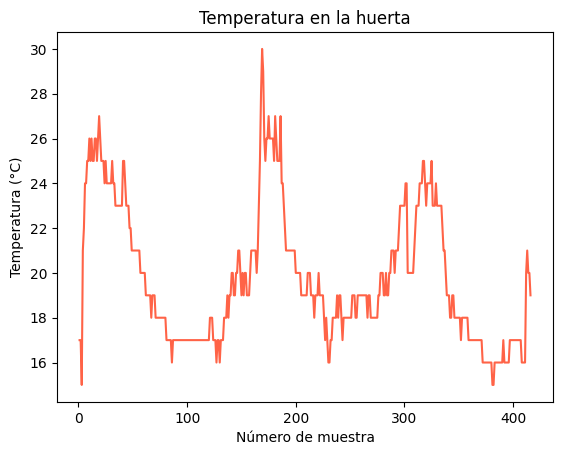

In [ ]:
plt.plot(df.Muestra, df.Temperatura, color="tomato")
plt.title("Temperatura en la huerta")
plt.xlabel("Número de muestra")
plt.ylabel("Temperatura (°C)")
plt.show()

**Ejercicio 4.1:** Haz la gráfica de la humedad del aire (`HumedadAire`). Elige un color de la lista de [colores web](https://es.wikipedia.org/wiki/Colores_web) y ponle título y nombres a los ejes.

In [ ]:
# Escribe tu código aquí

### Varias gráficas juntas

Con `plt.subplots` podemos poner varias gráficas una encima de otra y compararlas. `sharex=True` hace que compartan el eje horizontal.

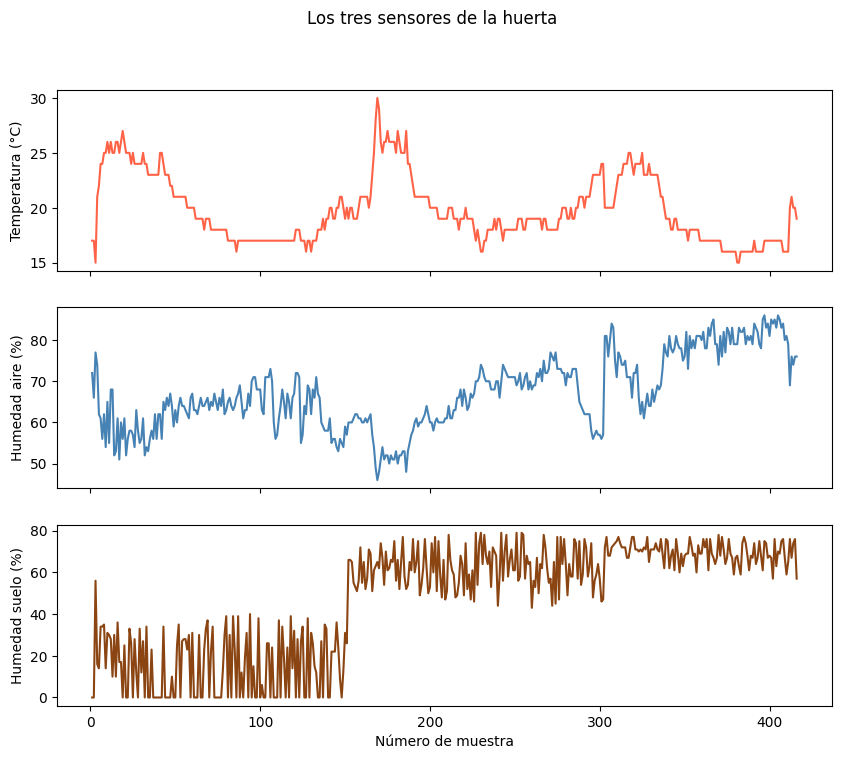

In [ ]:
fig, ejes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ejes[0].plot(df.Muestra, df.Temperatura, color="tomato")
ejes[0].set_ylabel("Temperatura (°C)")

ejes[1].plot(df.Muestra, df.HumedadAire, color="steelblue")
ejes[1].set_ylabel("Humedad aire (%)")

ejes[2].plot(df.Muestra, df.HumedadSuelo, color="saddlebrown")
ejes[2].set_ylabel("Humedad suelo (%)")
ejes[2].set_xlabel("Número de muestra")

fig.suptitle("Los tres sensores de la huerta")
plt.show()

**Para discutir en grupo:**

1. Cuando la temperatura **sube**, ¿qué pasa con la humedad del aire?
2. ¿Qué ves raro en la humedad del suelo en las primeras ~150 muestras?
3. Alrededor de la muestra 150 la humedad del suelo cambia de golpe. ¿Qué pudo pasar en la huerta? (¿regaron?, ¿movieron el sensor?, ¿llovió?)

## 5. Limpiar datos: ¿todos los datos son confiables? (15 min)

En la gráfica de humedad del suelo, el sensor salta de 0 a 30 y otra vez a 0 de una muestra a la siguiente. La tierra **no se seca y se moja tan rápido**. Lo más probable es que el sensor haya tenido **mal contacto** y marcara 0 por error.

Para encontrar esas filas usamos un **filtro**: una condición entre corchetes.

In [ ]:
ceros = df[df.HumedadSuelo == 0]
ceros

,Muestra,HumedadAire,Temperatura,HumedadSuelo
0,1,72,17,0
1,2,66,17,0
18,19,56,27,0
20,21,52,25,0
21,22,56,25,0
...,...,...,...,...
134,135,66,18,0
136,137,59,19,0
139,140,58,19,0
140,141,61,20,0


In [ ]:
print("Lecturas en cero:", len(ceros))
print("Porcentaje del total:", round(100 * len(ceros) / len(df), 1), "%")

Lecturas en cero: 65
Porcentaje del total: 15.6 %


¿En qué momento aparecen esos ceros? Marquémoslos con puntos rojos sobre la gráfica:

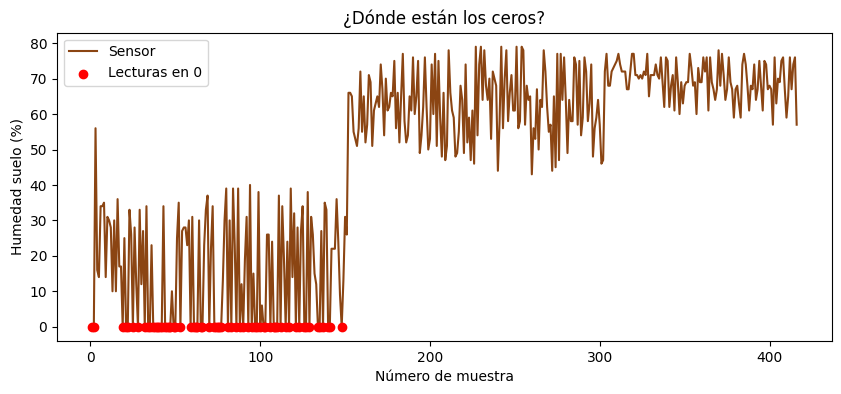

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df.Muestra, df.HumedadSuelo, color="saddlebrown", label="Sensor")
plt.scatter(ceros.Muestra, ceros.HumedadSuelo, color="red", zorder=3, label="Lecturas en 0")
plt.title("¿Dónde están los ceros?")
plt.xlabel("Número de muestra")
plt.ylabel("Humedad suelo (%)")
plt.legend()
plt.show()

Los ceros **solo** aparecen al comienzo. Un 0 de error no es lo mismo que "no hay agua", así que lo reemplazamos por `NaN` (*Not a Number*), que significa **"dato faltante"**. Pandas ignora los `NaN` al calcular promedios.

Creamos una **nueva columna** (como hicimos con los grados Celsius en la sesión 1):

In [ ]:
df["SueloLimpio"] = df.HumedadSuelo.replace(0, np.nan)
df.head(10)

,Muestra,HumedadAire,Temperatura,HumedadSuelo,SueloLimpio
0,1,72,17,0,NaN
1,2,66,17,0,NaN
2,3,77,15,56,56.0
3,4,74,21,16,16.0
4,5,62,22,14,14.0
5,6,61,24,34,34.0
6,7,56,24,34,34.0
7,8,62,25,35,35.0
8,9,54,25,14,14.0
9,10,65,26,31,31.0


In [ ]:
print("Promedio con los ceros:", round(df.HumedadSuelo.mean(), 1), "%")
print("Promedio sin los ceros:", round(df.SueloLimpio.mean(), 1), "%")

Promedio con los ceros: 47.2 %
Promedio sin los ceros: 55.9 %


😮 El resumen de la hoja de Excel dice que la humedad promedio del suelo es **47,2 %**, pero ese número incluye los errores del sensor. Al limpiar los datos, el promedio cambia **casi 9 puntos**.

> **Lección:** antes de sacar conclusiones, siempre hay que revisar si los datos tienen errores. Los datos sucios dan conclusiones equivocadas.

### Dos etapas del experimento

Alrededor de la muestra 150 el comportamiento del suelo cambió por completo. Separemos los datos en dos etapas con `np.where(condición, valor_si_sí, valor_si_no)`:

In [ ]:
df["Etapa"] = np.where(df.Muestra <= 150, "Antes", "Después")
round(df.groupby("Etapa")[["HumedadAire", "Temperatura", "SueloLimpio"]].mean(), 1)

,HumedadAire,Temperatura,SueloLimpio
Etapa,,,
Antes,62.6,19.9,26.5
Después,69.6,19.8,65.3


`groupby` agrupa las filas según una columna y calcula el promedio de cada grupo.

**Ejercicio 5.1:** ¿Cuántas lecturas de `SueloLimpio` están por debajo de 20 %? Pista: usa un filtro como el de los ceros, pero con `<`.

In [ ]:
# Escribe tu código aquí

## 6. Distribuciones: histogramas (10 min)

Un **histograma** agrupa los datos en intervalos (llamados *bins*) y cuenta cuántos datos caen en cada uno. Así vemos cuáles valores son comunes y cuáles son raros.

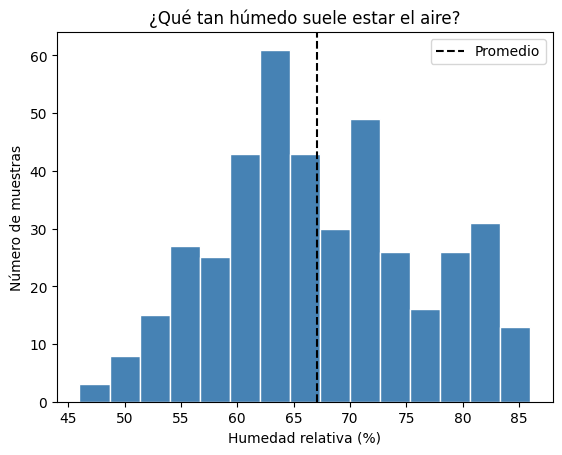

In [ ]:
plt.hist(df.HumedadAire, bins=15, color="steelblue", edgecolor="white")
plt.axvline(df.HumedadAire.mean(), color="black", linestyle="--", label="Promedio")
plt.title("¿Qué tan húmedo suele estar el aire?")
plt.xlabel("Humedad relativa (%)")
plt.ylabel("Número de muestras")
plt.legend()
plt.show()

Comparemos la humedad del suelo **antes** y **después** de limpiar:

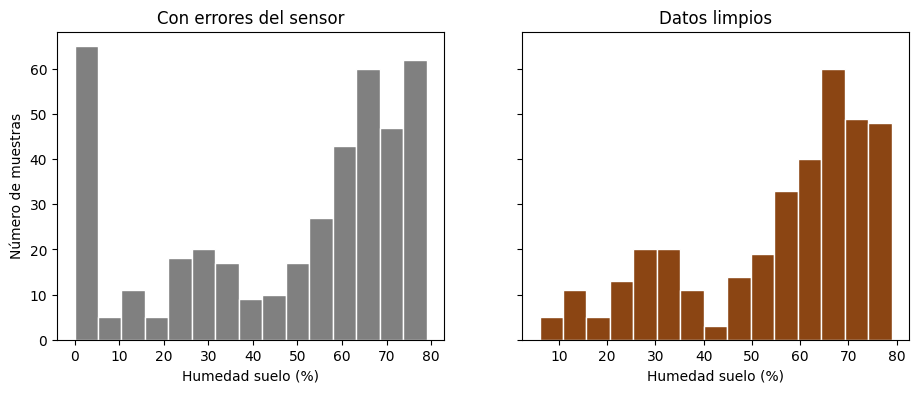

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ejes[0].hist(df.HumedadSuelo, bins=15, color="gray", edgecolor="white")
ejes[0].set_title("Con errores del sensor")
ejes[0].set_xlabel("Humedad suelo (%)")
ejes[0].set_ylabel("Número de muestras")

ejes[1].hist(df.SueloLimpio.dropna(), bins=15, color="saddlebrown", edgecolor="white")
ejes[1].set_title("Datos limpios")
ejes[1].set_xlabel("Humedad suelo (%)")

plt.show()

**Ejercicio 6.1:** Haz el histograma de la temperatura con 10 *bins*. Agrega una línea vertical en el promedio. ¿Cuál es la temperatura más común en la huerta?

In [ ]:
# Escribe tu código aquí

## 7. Relaciones entre variables (10 min)

En la sección 4 parecía que cuando sube la temperatura, baja la humedad del aire. Para comprobarlo usamos un **diagrama de dispersión**: cada punto es una muestra.

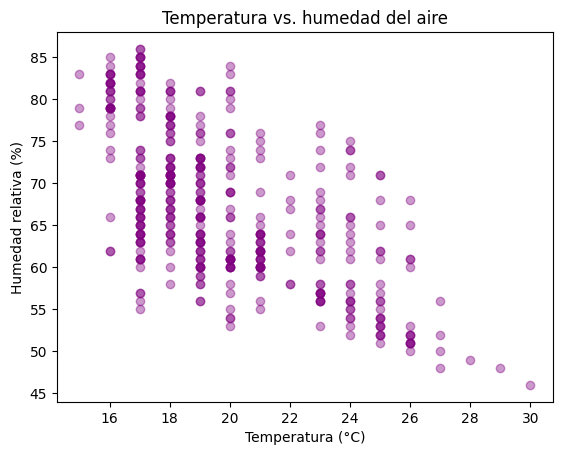

In [ ]:
plt.scatter(df.Temperatura, df.HumedadAire, alpha=0.4, color="purple")
plt.title("Temperatura vs. humedad del aire")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Humedad relativa (%)")
plt.show()

### La correlación

La **correlación** es un número entre **-1** y **1** que mide qué tanto se mueven juntas dos variables:

| Valor | Significado |
|---|---|
| cerca de **1** | cuando una sube, la otra también sube |
| cerca de **0** | no hay relación clara (en línea recta) |
| cerca de **-1** | cuando una sube, la otra baja |

In [ ]:
round(df[["HumedadAire", "Temperatura", "SueloLimpio"]].corr(), 2)

,HumedadAire,Temperatura,SueloLimpio
HumedadAire,1.00,-0.63,0.42
Temperatura,-0.63,1.00,-0.09
SueloLimpio,0.42,-0.09,1.00


### Una recta que resume la relación

`np.polyfit` encuentra la recta que mejor pasa por los puntos: $y = m\,x + b$, donde $m$ es la **pendiente**.

Pendiente m = -1.89
Intercepto b = 104.4


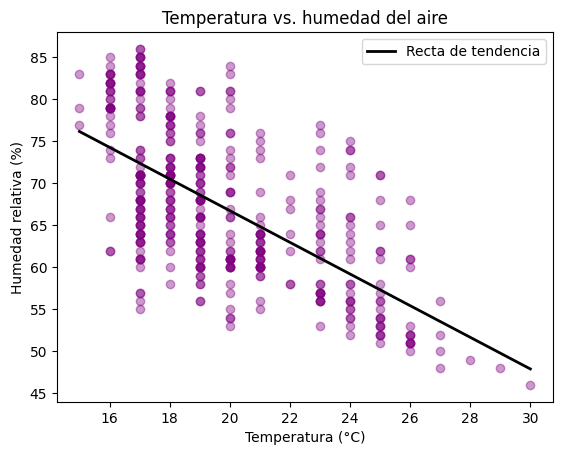

In [ ]:
m, b = np.polyfit(df.Temperatura, df.HumedadAire, 1)
print("Pendiente m =", round(m, 2))
print("Intercepto b =", round(b, 1))

x = np.linspace(df.Temperatura.min(), df.Temperatura.max(), 50)
plt.scatter(df.Temperatura, df.HumedadAire, alpha=0.4, color="purple")
plt.plot(x, m * x + b, color="black", linewidth=2, label="Recta de tendencia")
plt.title("Temperatura vs. humedad del aire")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Humedad relativa (%)")
plt.legend()
plt.show()

**¿Cómo se lee la pendiente?** Por cada grado que sube la temperatura, la humedad del aire **baja** cerca de 2 puntos porcentuales. El aire caliente puede contener más vapor de agua, por eso su humedad *relativa* baja.

**Ejercicio 7.1:** Haz el diagrama de dispersión de `Temperatura` contra `SueloLimpio`. ¿La temperatura del aire parece influir en la humedad de la tierra? Compara con el valor de la correlación.

In [ ]:
# Escribe tu código aquí

⚠️ **Cuidado:** que dos variables estén correlacionadas **no significa** que una cause la otra. Por ejemplo, la humedad del suelo tiene correlación alta con el *número de muestra*, pero el número de muestra no moja la tierra: lo que cambió fue algo que pasó en la huerta alrededor de la muestra 150.

## 8. Semáforo de riego (10 min)

Ahora usemos los datos para **tomar decisiones**. Clasificaremos cada lectura del suelo en tres niveles con `pd.cut`:

| Humedad del suelo | Estado |
|---|---|
| 0 – 30 % | 🔴 Seca: hay que regar |
| 30 – 60 % | 🟢 Adecuada |
| 60 – 100 % | 🔵 Muy húmeda: no regar |

*(Estos límites son un ejemplo. Los valores ideales dependen de la planta y del sensor: ¡pueden investigarlos!)*

In [ ]:
limites = [0, 30, 60, 100]
nombres = ["Seca", "Adecuada", "Muy húmeda"]

df["Estado"] = pd.cut(df.SueloLimpio, bins=limites, labels=nombres)
df.head(10)

,Muestra,HumedadAire,Temperatura,HumedadSuelo,SueloLimpio,Etapa,Estado
0,1,72,17,0,NaN,Antes,NaN
1,2,66,17,0,NaN,Antes,NaN
2,3,77,15,56,56.0,Antes,Adecuada
3,4,74,21,16,16.0,Antes,Seca
4,5,62,22,14,14.0,Antes,Seca
5,6,61,24,34,34.0,Antes,Adecuada
6,7,56,24,34,34.0,Antes,Adecuada
7,8,62,25,35,35.0,Antes,Adecuada
8,9,54,25,14,14.0,Antes,Seca
9,10,65,26,31,31.0,Antes,Adecuada


In [ ]:
conteo = df.Estado.value_counts().reindex(nombres)
conteo

,count
Estado,
Seca,54
Adecuada,104
Muy húmeda,193


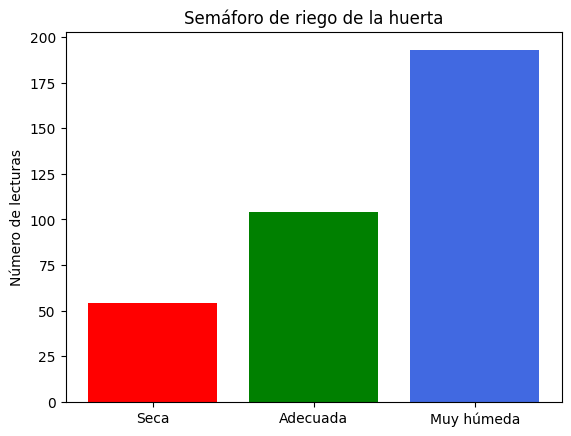

In [ ]:
plt.bar(conteo.index, conteo.values, color=["red", "green", "royalblue"])
plt.title("Semáforo de riego de la huerta")
plt.ylabel("Número de lecturas")
plt.show()

**Ejercicio 8.1:** Cuenta el estado del suelo en cada etapa (antes y después de la muestra 150). Pista: usa el filtro `df[df.Etapa == "Antes"]` y luego `.Estado.value_counts()`.

In [ ]:
# Escribe tu código aquí

Guardemos la tabla limpia y clasificada en un nuevo archivo de Excel (como en la sesión 1):

In [ ]:
df.to_excel("huerta_datos_limpios.xlsx", index=False)

## 9. Conclusiones (5 min)

Hoy hicimos el ciclo completo de la ciencia de datos:

1. **Cargar** datos reales (¡y desordenados!) desde Excel.
2. **Explorar** con estadísticas: promedio, mediana, mínimo y máximo.
3. **Visualizar** con series de tiempo, histogramas y diagramas de dispersión.
4. **Limpiar** los errores del sensor y ver cuánto cambian las conclusiones.
5. **Relacionar** variables con la correlación y una recta de tendencia.
6. **Decidir** con un semáforo de riego.

### Ideas para mejorar las próximas mediciones 🌿

- Anotar la **fecha y la hora** de cada muestra: así sabremos qué pasa de día y de noche.
- Llevar una **bitácora** de lo que pasa en la huerta: cuándo se riega, si llueve, si se mueve el sensor.
- Revisar que el sensor del suelo esté bien enterrado para evitar lecturas en cero.

### Reto para la casa

Cambia los límites del semáforo de riego a `[0, 40, 70, 100]` y vuelve a ejecutar la sección 8. ¿Cambian mucho los resultados?

## ⭐ Extra (si sobra tiempo): promedio móvil

Los sensores tienen "ruido": pequeños saltos que no son reales. Un **promedio móvil** reemplaza cada dato por el promedio de sus vecinos y suaviza la curva. Con `rolling(10)` usamos las últimas 10 muestras.

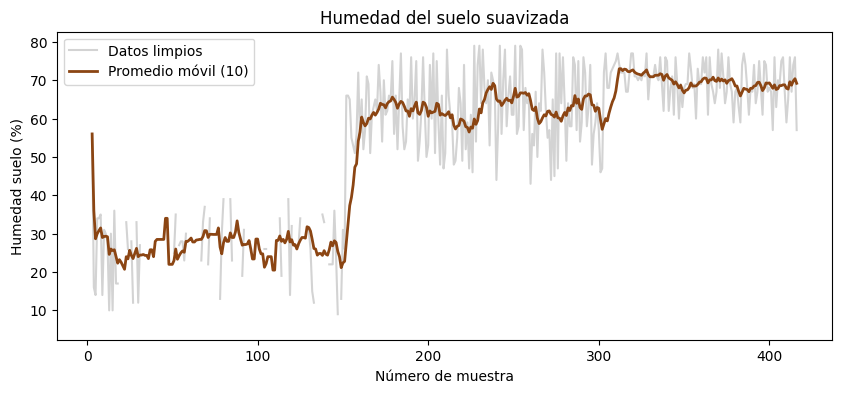

In [ ]:
df["SueloSuave"] = df.SueloLimpio.rolling(10, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(df.Muestra, df.SueloLimpio, color="lightgray", label="Datos limpios")
plt.plot(df.Muestra, df.SueloSuave, color="saddlebrown", linewidth=2, label="Promedio móvil (10)")
plt.title("Humedad del suelo suavizada")
plt.xlabel("Número de muestra")
plt.ylabel("Humedad suelo (%)")
plt.legend()
plt.show()

**Ejercicio extra:** Prueba con `rolling(3)` y `rolling(30)`. ¿Qué pasa con la curva cuando la ventana es más grande?

In [ ]:
# Escribe tu código aquí